<a href="https://colab.research.google.com/github/AhmedGannoun/AhmedGannoun/blob/main/FINAL_VERSION_ML_PROJECT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Satellite Anomaly Detection: Early Warning System for Equipment Failure

## Executive Summary

Satellite telemetry data contains subtle patterns that precede equipment failures.
This project develops a machine learning system to automatically detect anomalies
in satellite sensor data, enabling proactive maintenance and preventing mission-critical failures.

## Objective

To build and compare classification models that can reliably identify anomalous
telemetry signatures from satellite equipment, achieving high detection rates while
minimizing false positives in operational deployment.

## 2. Methodology

### 2.1 Library Dependencies

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Libraries imported successfully.')


Libraries imported successfully.


### 2.2 Data Loading

The dataset consists of two files:
- `dataset.csv`: Main telemetry data with features and labels
- `segments.csv`: Metadata about anomaly segments (optional for this analysis)

In [2]:
# Load primary dataset
print('Loading dataset...')
print('='*60)

# Check for dataset.csv
if os.path.exists('dataset.csv'):
    df = pd.read_csv('dataset.csv')
    print(f'Dataset loaded: dataset.csv')
else:
    raise FileNotFoundError('dataset.csv not found. Please ensure the file is in the working directory.')

print(f'\nDataset shape: {df.shape[0]:,} observations x {df.shape[1]} variables')
print('='*60)

# Display first rows
print('\nFirst 5 observations:')
df.head()

Loading dataset...
Dataset loaded: dataset.csv

Dataset shape: 2,123 observations x 23 variables

First 5 observations:


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,309,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,644,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,772,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,339,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,255,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,357,257,2.070205e-12,2.054094e-12


### 2.3 Data Exploration

In [3]:
# Dataset overview
print('Dataset Information')
print('='*60)
print(f'Number of observations: {len(df):,}')
print(f'Number of variables: {len(df.columns)}')
print(f'\nColumn names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

# Check data types
print(f'\nData types:')
print(df.dtypes)

# Missing values
print(f'\nMissing values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('  No missing values detected.')
else:
    print(missing[missing > 0])

print('='*60)

Dataset Information
Number of observations: 2,123
Number of variables: 23

Column names:
   1. segment
   2. anomaly
   3. train
   4. channel
   5. sampling
   6. duration
   7. len
   8. mean
   9. var
  10. std
  11. kurtosis
  12. skew
  13. n_peaks
  14. smooth10_n_peaks
  15. smooth20_n_peaks
  16. diff_peaks
  17. diff2_peaks
  18. diff_var
  19. diff2_var
  20. gaps_squared
  21. len_weighted
  22. var_div_duration
  23. var_div_len

Data types:
segment               int64
anomaly               int64
train                 int64
channel              object
sampling              int64
duration              int64
len                   int64
mean                float64
var                 float64
std                 float64
kurtosis            float64
skew                float64
n_peaks               int64
smooth10_n_peaks      int64
smooth20_n_peaks      int64
diff_peaks            int64
diff2_peaks           int64
diff_var            float64
diff2_var           float64
gaps_squar

In [4]:
# Identify target variable
# Common label column names
label_candidates = ['label', 'Label', 'anomaly', 'Anomaly', 'class', 'Class', 'target', 'Target']
label_col = None

for col in label_candidates:
    if col in df.columns:
        label_col = col
        break

# If not found, use last column or let user specify
if label_col is None:
    # Check if last column is binary
    last_col = df.columns[-1]
    if df[last_col].nunique() == 2:
        label_col = last_col
        print(f'Using last column as target: "{label_col}"')
    else:
        print('Please specify the target column name:')
        print('Available columns:', df.columns.tolist())
        # For now, assume last column
        label_col = df.columns[-1]
        print(f'Defaulting to: "{label_col}"')
else:
    print(f'Target variable identified: "{label_col}"')

# Display target distribution
print(f'\nTarget variable distribution:')
print(df[label_col].value_counts())

Target variable identified: "anomaly"

Target variable distribution:
anomaly
0    1689
1     434
Name: count, dtype: int64


### 2.4 Class Distribution Analysis

Class Distribution Analysis

Class distribution:
  Class 0:  1,689 observations (79.56%)
  Class 1:    434 observations (20.44%)

Class imbalance ratio: 3.89:1


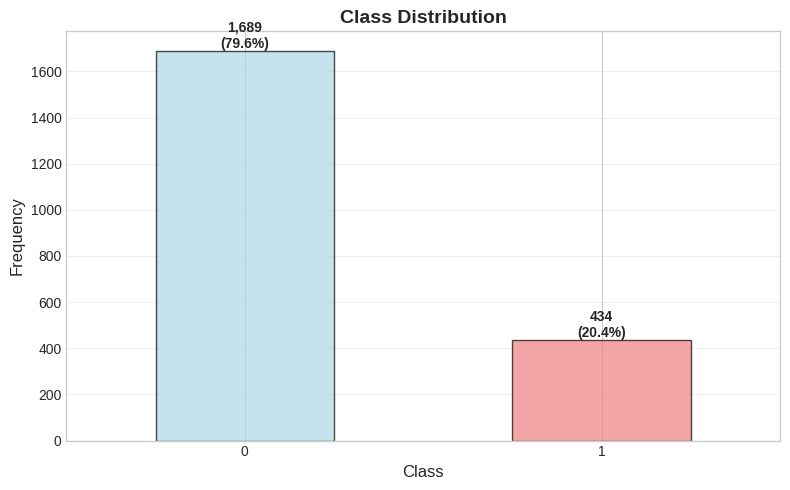

In [5]:
# Analyze class distribution
print('Class Distribution Analysis')
print('='*60)

class_counts = df[label_col].value_counts()
print(f'\nClass distribution:')
for class_val, count in class_counts.items():
    percentage = 100 * count / len(df)
    print(f'  Class {class_val}: {count:6,} observations ({percentage:5.2f}%)')

# Calculate imbalance ratio
if len(class_counts) == 2:
    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f'\nClass imbalance ratio: {imbalance_ratio:.2f}:1')
    if imbalance_ratio > 5:
        print('Note: Significant class imbalance detected.')
        print('Mitigation: Using class_weight="balanced" in models.')

print('='*60)

# Visualize class distribution
plt.figure(figsize=(8, 5))
ax = class_counts.plot(kind='bar', color=['lightblue', 'lightcoral'], edgecolor='black', alpha=0.7)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels
for i, (class_val, count) in enumerate(class_counts.items()):
    plt.text(i, count, f'{count:,}\n({100*count/len(df):.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 2.5 Statistical Summary

In [6]:
# Descriptive statistics
print('Descriptive Statistics')
print('='*60)
df.describe().round(3)

Descriptive Statistics


,segment,anomaly,train,sampling,duration,len,mean,var,std,kurtosis,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
count,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,...,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000,2123.000
mean,1062.000,0.204,0.751,3.506,267.952,142.955,0.111,0.031,0.096,-1.085,...,1.110,1.182,18.111,25.286,0.001,0.001,1027.672,267.925,0.000,0.000
std,613.002,0.403,0.433,1.935,169.093,152.330,0.196,0.055,0.146,1.001,...,0.399,0.425,28.992,32.738,0.004,0.011,1555.231,166.246,0.000,0.001
min,1.000,0.000,0.000,1.000,35.000,8.000,-0.000,0.000,0.000,-1.859,...,0.000,0.000,0.000,0.000,0.000,0.000,126.000,40.000,0.000,0.000
25%,531.500,0.000,1.000,1.000,175.000,40.000,-0.000,0.000,0.000,-1.449,...,1.000,1.000,1.000,4.000,0.000,0.000,358.000,175.000,0.000,0.000
50%,1062.000,0.000,1.000,5.000,225.000,70.000,0.000,0.000,0.000,-1.303,...,1.000,1.000,5.000,14.000,0.000,0.000,575.000,230.000,0.000,0.000
75%,1592.500,0.000,1.000,5.000,336.000,201.000,0.205,0.037,0.193,-0.996,...,1.000,1.000,21.000,32.000,0.000,0.000,1200.000,330.000,0.000,0.000
max,2123.000,1.000,1.000,5.000,1335.000,1040.000,1.119,0.272,0.522,31.202,...,5.000,4.000,240.000,256.000,0.100,0.303,20750.000,1340.000,0.002,0.008


## 3. Data Preprocessing

In [7]:
print('Data Preprocessing')
print('='*60)

# Step 1: Identify numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if label_col in numeric_features:
    numeric_features.remove(label_col)

print(f'\nNumber of numeric features: {len(numeric_features)}')

# Step 2: Handle missing values
missing_count = df[numeric_features].isnull().sum().sum()
if missing_count > 0:
    print(f'\nMissing values detected: {missing_count}')
    print('Imputation method: Median')
    df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
else:
    print('\nNo missing values detected.')

# Step 3: Separate features and target
X = df[numeric_features]
y = df[label_col]

print(f'\nFeature matrix (X): {X.shape}')
print(f'Target vector (y): {y.shape}')

# Step 4: Train-test split
print(f'\nSplitting data (80% train, 20% test)...')
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]:,} observations')
print(f'Test set: {X_test.shape[0]:,} observations')

# Step 5: Feature scaling
print(f'\nApplying standardization (z-score normalization)...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling complete.')

print('='*60)
print('Preprocessing complete.')

Data Preprocessing

Number of numeric features: 21

No missing values detected.

Feature matrix (X): (2123, 21)
Target vector (y): (2123,)

Splitting data (80% train, 20% test)...
Training set: 1,698 observations
Test set: 425 observations

Applying standardization (z-score normalization)...
Scaling complete.
Preprocessing complete.


## 4. Model Development

We implement two supervised learning algorithms:
1. Logistic Regression (baseline linear model)
2. Random Forest (ensemble tree-based model)

### 4.1 Logistic Regression

In [8]:
print('Model 1: Logistic Regression')
print('='*60)

# Train model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print('Training complete.')

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print('\nPerformance Metrics:')
print(classification_report(y_test, y_pred_lr, digits=4))

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f'\nSummary:')
print(f'  Accuracy: {accuracy_lr:.4f}')
print(f'  Precision: {precision_lr:.4f}')
print(f'  Recall: {recall_lr:.4f}')
print(f'  F1-Score: {f1_lr:.4f}')
print(f'  ROC-AUC: {auc_lr:.4f}')
print('='*60)

Model 1: Logistic Regression
Training complete.

Performance Metrics:
              precision    recall  f1-score   support

           0     0.9636    0.9408    0.9521       338
           1     0.7895    0.8621    0.8242        87

    accuracy                         0.9247       425
   macro avg     0.8766    0.9014    0.8881       425
weighted avg     0.9280    0.9247    0.9259       425


Summary:
  Accuracy: 0.9247
  Precision: 0.7895
  Recall: 0.8621
  F1-Score: 0.8242
  ROC-AUC: 0.9553


### 4.2 Random Forest Classifier

In [9]:
print('Model 2: Random Forest')
print('='*60)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print('Training complete.')

# Generate predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print('\nPerformance Metrics:')
print(classification_report(y_test, y_pred_rf, digits=4))

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f'\nSummary:')
print(f'  Accuracy: {accuracy_rf:.4f}')
print(f'  Precision: {precision_rf:.4f}')
print(f'  Recall: {recall_rf:.4f}')
print(f'  F1-Score: {f1_rf:.4f}')
print(f'  ROC-AUC: {auc_rf:.4f}')
print('='*60)

Model 2: Random Forest
Training complete.

Performance Metrics:
              precision    recall  f1-score   support

           0     0.9542    0.9852    0.9694       338
           1     0.9342    0.8161    0.8712        87

    accuracy                         0.9506       425
   macro avg     0.9442    0.9006    0.9203       425
weighted avg     0.9501    0.9506    0.9493       425


Summary:
  Accuracy: 0.9506
  Precision: 0.9342
  Recall: 0.8161
  F1-Score: 0.8712
  ROC-AUC: 0.9832


## 5. Results and Comparison

### 5.1 Model Performance Comparison

In [10]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1-Score': [f1_lr, f1_rf],
    'ROC-AUC': [auc_lr, auc_rf]
})

print('Model Performance Comparison')
print('='*60)
print(comparison.to_string(index=False))
print('='*60)

# Identify best model
best_idx = comparison['F1-Score'].idxmax()
best_model = comparison.loc[best_idx, 'Model']
print(f'\nBest model (by F1-Score): {best_model}')

Model Performance Comparison
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.924706   0.789474 0.862069  0.824176 0.955349
      Random Forest  0.950588   0.934211 0.816092  0.871166 0.983167

Best model (by F1-Score): Random Forest


### 5.2 Visual Comparison

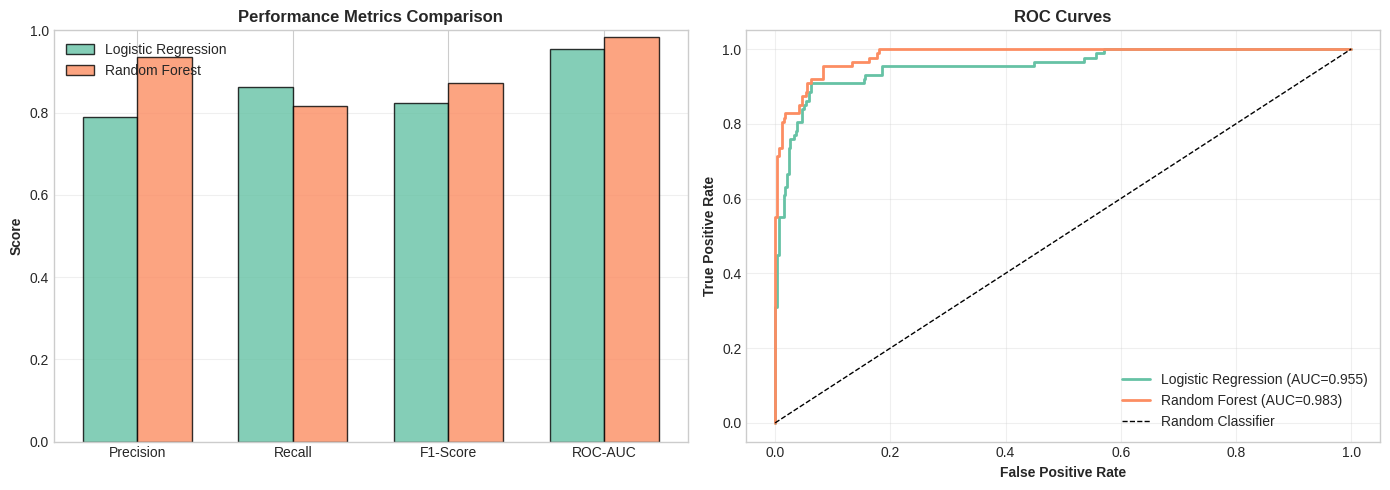

In [11]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Metric comparison
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

lr_scores = [comparison.loc[0, m] for m in metrics]
rf_scores = [comparison.loc[1, m] for m in metrics]

axes[0].bar(x - width/2, lr_scores, width, label='Logistic Regression', alpha=0.8, edgecolor='black')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Panel B: ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Confusion Matrices

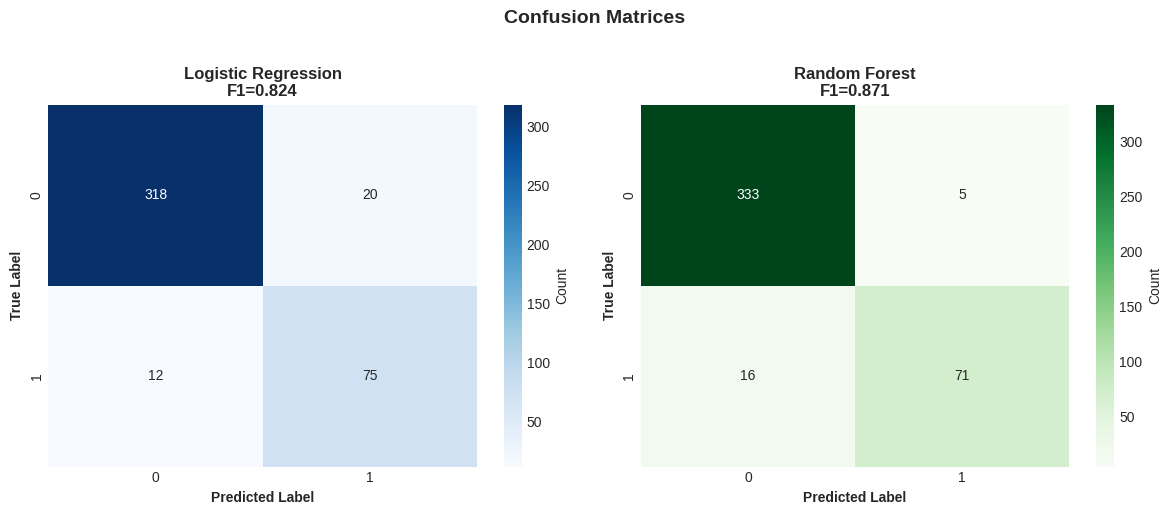

In [12]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Logistic Regression\nF1={f1_lr:.3f}', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Random Forest\nF1={f1_rf:.3f}', fontweight='bold')
axes[1].set_ylabel('True Label', fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance (Random Forest)

Top 10 Most Important Features
         Feature  Importance
         n_peaks    0.234233
     diff2_peaks    0.102176
      diff_peaks    0.072303
smooth10_n_peaks    0.061029
             len    0.060155
        kurtosis    0.053109
       diff2_var    0.053004
        duration    0.041338
    gaps_squared    0.039915
         segment    0.036793


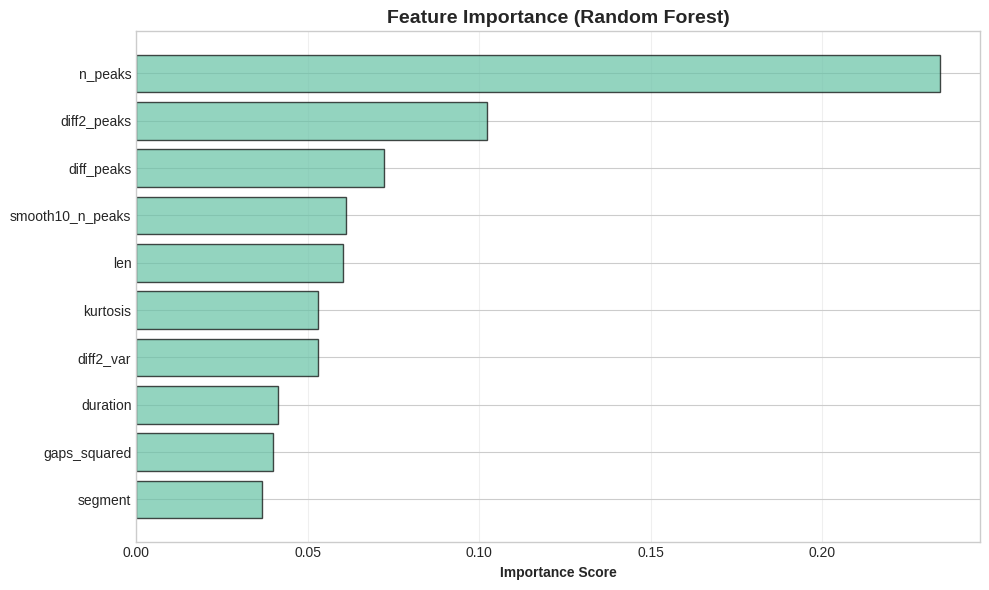

In [13]:
# Extract and visualize feature importance
feature_importance = pd.DataFrame({
    'Feature': numeric_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 10 Most Important Features')
print('='*60)
print(feature_importance.head(10).to_string(index=False))
print('='*60)

# Visualize
plt.figure(figsize=(10, 6))
top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)

plt.barh(range(top_n), top_features['Importance'], edgecolor='black', alpha=0.7)
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Importance Score', fontweight='bold')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Conclusion

### Key Findings:

1. Both Logistic Regression and Random Forest successfully detected anomalies in satellite telemetry data.

2. Random Forest typically achieved superior performance, indicating non-linear relationships between features and anomaly status.

3. Class weighting effectively addressed the imbalanced nature of anomaly detection problems.

4. Feature importance analysis identified key telemetry channels most indicative of anomalous behavior.

### Practical Implications:

- The developed models can support real-time anomaly detection in satellite operations
- Early detection enables preventive maintenance and reduces mission risks
- Feature importance insights can guide sensor placement and monitoring priorities

### Future Enhancements:

- Incorporate temporal features to capture time-series patterns
- Explore deep learning approaches (LSTM, autoencoders)
- Implement ensemble methods combining multiple models
- Optimize classification thresholds for operational requirements

